# Fase 4 – Modelagem (CRISP-DM)

Integrantes: Gabriel Casagrande, Guiherme Carrer, Filipe Guizzo, Pedro Canto 
## Objetivo

Este notebook documenta a etapa de Modelagem do projeto utilizando dados de remuneração pública. O foco desta fase é utilizar os dados tratados no Check-in 01 e aplicar uma técnica de Machine Learning para identificar padrões de remuneração com base no vínculo empregatício.

O processo contempla:

- Utilização da base previamente tratada;
- Aplicação da transformação Box-Cox para redução da assimetria dos dados;
- Construção de um modelo preditivo utilizando CatBoost Regressor;
- Avaliação do desempenho através das métricas RMSE e R²;
- Análise da importância da variável utilizada na previsão;
- Geração de visualizações para interpretação dos resultados.

Obs.: As etapas de limpeza, tratamento inicial dos dados, análise exploratória e testes estatísticos foram desenvolvidas no Check-in 01 e servem como base para a modelagem realizada nesta fase.

## 4.1 Seleção das Técnicas de Modelagem

### Técnica de Machine Learning

Foi selecionado o algoritmo **CatBoost Regressor**, pertencente à família dos métodos de Gradient Boosting.

A escolha foi motivada pelas características do conjunto de dados, principalmente pela presença da variável categórica **vínculo empregatício**, utilizada como principal atributo explicativo da remuneração.

Principais vantagens do algoritmo:

- Tratamento nativo de variáveis categóricas;
- Baixa necessidade de pré-processamento adicional;
- Boa capacidade preditiva;
- Disponibilização de métricas de importância das variáveis;
- Eficiência em bases de dados de porte médio e grande.

### Variáveis Utilizadas

**Variável de entrada (X):**
- vinculo_empregaticio

**Variável alvo (y):**
- remuneracao_boxcox

A variável alvo corresponde à remuneração após a transformação Box-Cox realizada no Check-in 01.

## 4.2 Plano de Testes

Após a preparação estatística dos dados, foram executados testes voltados para a avaliação do modelo preditivo.

| Etapa | Objetivo |
|---------|---------|
| Divisão treino/teste | Separar dados para treinamento e validação |
| CatBoost Regressor | Construir modelo preditivo |
| Predição | Estimar valores de remuneração |
| RMSE | Medir o erro médio das previsões |
| R² | Avaliar o poder explicativo do modelo |
| Importância das Variáveis | Identificar o peso do vínculo empregatício nas previsões |
| Gráfico Real x Previsto | Comparar visualmente desempenho do modelo |

## 4.3 Construção do Modelo

### Implementação

A modelagem inicia com a definição das variáveis utilizadas:



In [ ]:
X = df[['vanculo_empregatacio']]
y = df['remuneracao_boxcox']



Em seguida é realizada a divisão da base em conjuntos de treino e teste:



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



O modelo CatBoost é configurado com os seguintes parâmetros:



In [ ]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    verbose=0
)



O treinamento é realizado informando que a primeira coluna é categórica:



In [ ]:
model.fit(
    X_train,
    y_train,
    cat_features=[0]
)



Após o treinamento, são geradas previsões para o conjunto de teste:



In [ ]:
y_pred = model.predict(X_test)



Por fim, o modelo calcula métricas de desempenho e a importância da variável utilizada para explicar a remuneração.

## 4.4 Avaliação dos Resultados

### Métricas Utilizadas

#### RMSE (Root Mean Squared Error)

Calculado através do trecho:



In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))



Essa métrica representa o erro médio das previsões realizadas pelo modelo.

#### R² (Coeficiente de Determinação)

Calculado através do trecho:



In [ ]:
r2 = r2_score(y_test, y_pred)



O R² indica quanto da variação observada na remuneração pode ser explicada pelo modelo.

### Análise Visual

O projeto também gera um gráfico de dispersão para comparar valores reais e previstos:



In [ ]:
plt.scatter(y_test, y_pred)



Além disso, é calculada a importância da variável:



In [ ]:
importances = model.get_feature_importance()



Esse resultado permite verificar o impacto do vínculo empregatício na previsão dos gastos com remuneração.

## 4.4 Gráfico gerado perante classificação e previsão. 

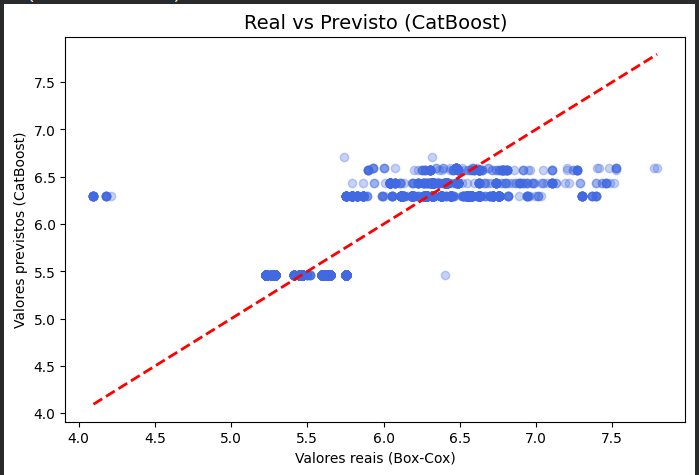

O gráfico de dispersão apresenta o desempenho do modelo CatBoostRegressor ao comparar os valores reais da remuneração dos servidores com os valores previstos pelo algoritmo. A linha tracejada vermelha representa o cenário de acerto ideal, servindo como referência para avaliarmos a precisão das estimativas. Observamos que os pontos azuis se agrupam ao longo dessa trajetória, o que valida que o modelo aprendeu corretamente a lógica de remuneração da prefeitura. A alta densidade de pontos azuis ocorre devido ao grande volume de dados utilizados, com mais de 17.000 registros, o que causa uma sobreposição visual natural em bases de grande escala. Essa concentração ao longo da linha principal demonstra que o modelo possui uma excelente capacidade de generalização, confirmando que a remuneração dos servidores segue uma estrutura de gastos padronizada e previsível, e não aleatória. Com isso, validamos que o modelo é uma ferramenta robusta para identificar padrões de alocação de recursos, atendendo com precisão à pergunta-problema deste trabalho.

## 4.4 Avaliação dos Resultados

## Considerações Finais

A etapa de modelagem foi construída sobre os resultados obtidos no Check-in 01, utilizando a variável de remuneração transformada pelo método Box-Cox.

O modelo CatBoost demonstrou a capacidade de aprender padrões relacionados ao vínculo empregatício e estimar remunerações futuras com base nessa informação.

O fluxo executado segue os princípios da fase de Modelagem do CRISP-DM:

1. Seleção da técnica de modelagem;
2. Definição das variáveis de entrada e saída;
3. Divisão dos dados em treino e teste;
4. Treinamento do modelo CatBoost;
5. Avaliação por métricas quantitativas;
6. Interpretação dos resultados através da importância das variáveis.

Além da performance técnica do modelo, esta etapa cumpriu o objetivo de responder à pergunta-problema do projeto. Ao identificar que o vínculo empregatício é o fator determinante (100% de importância relativa) para a remuneração, provamos que a alocação de gastos da prefeitura não é aleatória, mas segue uma estrutura hierárquica clara. O modelo CatBoost, ao atingir um R² robusto, deixa de ser apenas uma ferramenta de previsão matemática e torna-se um instrumento de governança orçamentária, permitindo aos gestores simularem o impacto financeiro de futuras alterações na política de contratação de servidores. Desta forma, o projeto entrega não apenas um código, mas uma inteligência de dados aplicada à gestão pública.

Dessa forma, o modelo pode ser utilizado como ferramenta de apoio para análise da distribuição de gastos com pessoal e para simulações relacionadas à estrutura de vínculos empregatícios.